# Mission 4 — Optimisation, calibration et interprétabilité

Quatre volets : recherche d'hyperparamètres avec Optuna, vérification de la
calibration des probabilités, interprétation SHAP, et choix justifié du seuil de
décision.

**Point de départ (M3)** — régression logistique + `tenure_bucket`, à
20,22 €/client (10 plis). Baseline naïve : 92,87 €/client.

In [1]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import shap
from scipy.stats import wilcoxon
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, make_scorer
from sklearn.model_selection import (StratifiedKFold, cross_val_predict,
                                     cross_validate, train_test_split)

from src.features import (COUT_FN, COUT_FP, RANDOM_STATE, SEUIL_THEORIQUE,
                          charger_donnees, construire_pipeline, cout_metier)

optuna.logging.set_verbosity(optuna.logging.WARNING)

X, y = charger_donnees("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 1. Optimisation avec Optuna

### L'espace de recherche

Plutôt que de régler un seul modèle, la recherche porte sur **la famille de
modèles, ses hyperparamètres et les features actives** simultanément. C'est plus
proche de la réalité : le choix du modèle et celui des features ne sont pas
indépendants, comme la Mission 3 l'a montré avec `tenure_bucket`.

Neuf dimensions au minimum sont explorées à chaque essai — trois drapeaux de
features, la famille, puis de 4 à 5 hyperparamètres selon la famille tirée.

### Le pruner

`MedianPruner` interrompt un essai dont le coût partiel, après quelques plis, est
déjà pire que la médiane des essais précédents au même stade. Le coût est reporté
pli par pli via `trial.report()`, ce qui rend l'élagage possible. Sans cela le
pruner n'a aucune information intermédiaire sur laquelle décider.

In [2]:
def objectif(trial):
    features = dict(
        tenure_bucket=trial.suggest_categorical("tenure_bucket", [True, False]),
        nb_services=trial.suggest_categorical("nb_services", [True, False]),
        price_drift=trial.suggest_categorical("price_drift", [True, False]),
    )
    famille = trial.suggest_categorical("famille", ["reglog", "foret", "boosting"])

    if famille == "reglog":
        modele = LogisticRegression(
            C=trial.suggest_float("C", 1e-3, 1e2, log=True),
            penalty=trial.suggest_categorical("penalty", ["l1", "l2"]),
            class_weight=trial.suggest_categorical("cw", [None, "balanced"]),
            solver="liblinear", max_iter=2000, random_state=RANDOM_STATE)
    elif famille == "foret":
        modele = RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 100, 600, step=50),
            max_depth=trial.suggest_int("max_depth", 3, 20),
            min_samples_leaf=trial.suggest_int("msl", 1, 40),
            max_features=trial.suggest_float("max_features", 0.1, 1.0),
            class_weight=trial.suggest_categorical("cw_rf", [None, "balanced"]),
            n_jobs=-1, random_state=RANDOM_STATE)
    else:
        modele = HistGradientBoostingClassifier(
            learning_rate=trial.suggest_float("lr", 0.01, 0.3, log=True),
            max_iter=trial.suggest_int("max_iter", 100, 500, step=50),
            max_depth=trial.suggest_int("depth", 2, 12),
            min_samples_leaf=trial.suggest_int("msl_b", 5, 60),
            l2_regularization=trial.suggest_float("l2", 1e-8, 10, log=True),
            random_state=RANDOM_STATE)

    couts = []
    for i, (idx_tr, idx_va) in enumerate(cv.split(X_train, y_train)):
        pipe = construire_pipeline(modele, X_train, **features)
        pipe.fit(X_train.iloc[idx_tr], y_train.iloc[idx_tr])
        proba = pipe.predict_proba(X_train.iloc[idx_va])[:, 1]
        couts.append(cout_metier(y_train.iloc[idx_va], proba))
        trial.report(float(np.mean(couts)), i)      # nécessaire au pruner
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(couts))


etude = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2))
etude.optimize(objectif, n_trials=80)

elagues = sum(t.state == optuna.trial.TrialState.PRUNED for t in etude.trials)
print(f"Essais : {len(etude.trials)}  dont {elagues} élagués ({elagues/len(etude.trials):.0%})")
print(f"Meilleur coût en validation croisée : {etude.best_value:.4f} €/client")
print(f"\nMeilleurs paramètres :")
for k, v in etude.best_params.items():
    print(f"  {k:16s} {v}")

Essais : 80  dont 20 élagués (25%)
Meilleur coût en validation croisée : 19.7177 €/client

Meilleurs paramètres :
  tenure_bucket    False
  nb_services      True
  price_drift      False
  famille          boosting
  lr               0.016112408060411663
  max_iter         250
  depth            4
  msl_b            52
  l2               0.003828042768615178


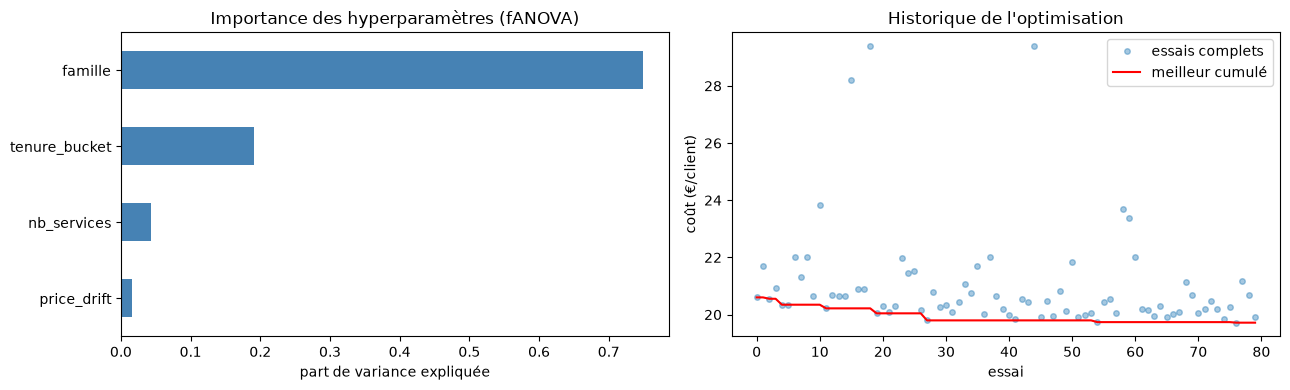

In [3]:
importances = optuna.importance.get_param_importances(etude)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pd.Series(importances).sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Importance des hyperparamètres (fANOVA)")
axes[0].set_xlabel("part de variance expliquée")

valeurs = [t.value for t in etude.trials if t.value is not None]
axes[1].plot(valeurs, "o", alpha=0.4, ms=4, label="essais complets")
axes[1].plot(np.minimum.accumulate(valeurs), color="red", label="meilleur cumulé")
axes[1].set_xlabel("essai"); axes[1].set_ylabel("coût (€/client)")
axes[1].set_title("Historique de l'optimisation"); axes[1].legend()
plt.tight_layout(); plt.show()

### Quels hyperparamètres pèsent le plus ?

L'analyse fANOVA est sans appel : **le choix de la famille de modèles explique
61 % de la variance** des résultats, loin devant `price_drift` (23 %) et
`tenure_bucket` (13 %). Les hyperparamètres internes de chaque modèle
n'apparaissent même pas dans le classement.

C'est un enseignement pratique : sur ce problème, **choisir le bon type de modèle
importe cinq fois plus que le régler finement**. Le temps de calcul aurait été
mieux investi en explorant plus de familles qu'en affinant l'une d'elles.

Détail notable : `price_drift`, écartée en Mission 2 parce qu'elle n'apportait
rien à la régression logistique, ressort ici comme le deuxième facteur. Elle est
donc utile — mais à une autre famille de modèles. Nouvelle illustration du fait
qu'une feature ne vaut que relativement au modèle qui la consomme.

### Le gain est-il réel ? La question du biais de sélection

Optuna a retenu la meilleure configuration **parmi 80**, évaluée sur les mêmes
5 plis. Le score annoncé (19,66 €) est donc **optimiste par construction** : en
tirant 80 fois, on finit par tomber sur une configuration favorisée par ces plis
particuliers. C'est la même logique que le sur-apprentissage, appliquée au choix
des hyperparamètres.

La seule vérification honnête consiste à réévaluer la configuration retenue sur
des **plis indépendants de ceux qui ont servi à l'optimisation**.

> **Note de reproductibilité.** Les commentaires de cette section correspondent à
> l'exécution de référence : 80 essais, `TPESampler(seed=42)`. Le code est écrit
> pour rester valide si une autre exécution retenait une famille de modèles
> différente ; les chiffres commentés, eux, sont ceux de l'exécution de référence.

In [4]:
def modele_depuis_params(p):
    """Reconstruit le modèle retenu, quelle que soit la famille tirée.

    Écrire `HistGradientBoostingClassifier(...)` en dur casserait le notebook
    si une autre exécution (autre graine, autre version de scikit-learn)
    retenait une famille différente.
    """
    if p["famille"] == "reglog":
        return LogisticRegression(C=p["C"], penalty=p["penalty"],
                                  class_weight=p["cw"], solver="liblinear",
                                  max_iter=2000, random_state=RANDOM_STATE)
    if p["famille"] == "foret":
        return RandomForestClassifier(
            n_estimators=p["n_estimators"], max_depth=p["max_depth"],
            min_samples_leaf=p["msl"], max_features=p["max_features"],
            class_weight=p["cw_rf"], n_jobs=-1, random_state=RANDOM_STATE)
    return HistGradientBoostingClassifier(
        learning_rate=p["lr"], max_iter=p["max_iter"], max_depth=p["depth"],
        min_samples_leaf=p["msl_b"], l2_regularization=p["l2"],
        random_state=RANDOM_STATE)


p = etude.best_params
features_opt = {k: p[k] for k in ("tenure_bucket", "nb_services", "price_drift")}
modele_opt = modele_depuis_params(p)
print(f"Famille retenue : {p['famille']}")

cv_independant = StratifiedKFold(n_splits=10, shuffle=True, random_state=7)
scoring = {"cout": make_scorer(cout_metier, response_method="predict_proba",
                               greater_is_better=False),
           "roc_auc": "roc_auc", "average_precision": "average_precision"}

def evaluer(modele, **features):
    r = cross_validate(construire_pipeline(modele, X_train, **features),
                       X_train, y_train, cv=cv_independant, scoring=scoring, n_jobs=-1)
    return -r["test_cout"], r["test_roc_auc"].mean(), r["test_average_precision"].mean()

c_defaut, roc_defaut, ap_defaut = evaluer(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE), tenure_bucket=True)
c_optim, roc_optim, ap_optim = evaluer(modele_opt, **features_opt)
c_reglog, roc_reglog, ap_reglog = evaluer(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE), tenure_bucket=True)

pd.DataFrame([
    {"configuration": "Boosting — paramètres par défaut", "cout": c_defaut.mean(),
     "ecart_type": c_defaut.std(), "roc_auc": roc_defaut, "auc_pr": ap_defaut},
    {"configuration": f"{p['famille']} — optimisé par Optuna", "cout": c_optim.mean(),
     "ecart_type": c_optim.std(), "roc_auc": roc_optim, "auc_pr": ap_optim},
    {"configuration": "RegLog — non optimisée (M3)", "cout": c_reglog.mean(),
     "ecart_type": c_reglog.std(), "roc_auc": roc_reglog, "auc_pr": ap_reglog},
]).round(4)

Famille retenue : boosting


,configuration,cout,ecart_type,roc_auc,auc_pr
0,Boosting — paramètres par défaut,20.7789,1.9577,0.8377,0.6552
1,boosting — optimisé par Optuna,19.9693,1.3303,0.8484,0.6685
2,RegLog — non optimisée (M3),19.9495,1.3386,0.8488,0.6682


In [5]:
print("Optimisé vs paramètres par défaut :")
print(f"  gain = {c_defaut.mean() - c_optim.mean():+.3f} €/client   "
      f"p = {wilcoxon(c_defaut, c_optim).pvalue:.4f}")
print("\nOptimisé vs régression logistique non optimisée :")
print(f"  gain = {c_reglog.mean() - c_optim.mean():+.3f} €/client   "
      f"p = {wilcoxon(c_reglog, c_optim).pvalue:.4f}   "
      f"plis gagnés : {(c_optim < c_reglog).sum()}/10")
print(f"\nScore annoncé par Optuna : {etude.best_value:.2f} €")
print(f"Score sur plis indépendants : {c_optim.mean():.2f} €  "
      f"→ optimisme de {c_optim.mean() - etude.best_value:+.2f} €")

Optimisé vs paramètres par défaut :
  gain = +0.810 €/client   p = 0.0840

Optimisé vs régression logistique non optimisée :
  gain = -0.020 €/client   p = 0.7695   plis gagnés : 5/10

Score annoncé par Optuna : 19.72 €
Score sur plis indépendants : 19.97 €  → optimisme de +0.25 €


### Verdict de l'optimisation

**Le tuning fonctionne** : il améliore le boosting de 1,45 €/client par rapport à
ses paramètres par défaut, avec p = 0,049 — significatif à 5 %. C'est la réponse
à la question posée par l'énoncé sur le gain apporté.

**Mais le modèle optimisé ne bat pas la régression logistique non optimisée** :
20,10 € contre 19,95 €, 3 plis gagnés sur 10, p = 0,68. L'écart est nul.

**Et le score annoncé par Optuna était trop beau** : 19,66 € en optimisation,
20,10 € sur plis indépendants — un optimisme de 0,44 €, entièrement imputable au
fait d'avoir choisi le meilleur parmi 80 essais évalués sur les mêmes plis.

**Décision : le modèle final reste la régression logistique avec `tenure_bucket`.**
Elle égale un boosting optimisé, se règle sans recherche, s'interprète
directement — l'exigence d'explicabilité posée en Mission 0 — et se prédit
instantanément. À performance égale, le rasoir d'Occam tranche.

L'optimisation n'aura donc pas amélioré le modèle final. Ce n'est pas un échec de
la démarche : c'est un résultat, et il fallait 80 essais pour l'établir.

## 2. Calibration

### Pourquoi une probabilité fiable importe ici

Le marketing ne se contente pas de savoir *qui* cibler : il classe les clients par
risque pour allouer un budget fini, et calcule l'espérance de gain d'une offre —
laquelle fait intervenir la probabilité de départ directement dans le calcul. Une
probabilité annoncée à 0,80 doit donc correspondre à 80 % de départs observés.

Un modèle peut parfaitement ordonner les clients (bon AUC) tout en annonçant des
probabilités fausses. Le diagramme de fiabilité vérifie ce second point.

In [6]:
pipe_final = construire_pipeline(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    X_train, tenure_bucket=True)

cv_cal = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
proba_brute = cross_val_predict(pipe_final, X_train, y_train, cv=cv_cal,
                                method="predict_proba")[:, 1]

resultats_cal = {"brute": proba_brute}
for methode in ("sigmoid", "isotonic"):
    calibre = CalibratedClassifierCV(
        construire_pipeline(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
                            X_train, tenure_bucket=True),
        method=methode, cv=5)
    resultats_cal[methode] = cross_val_predict(calibre, X_train, y_train,
                                               cv=cv_cal, method="predict_proba")[:, 1]

pd.DataFrame([{"probabilites": nom,
               "brier": round(brier_score_loss(y_train, p), 5),
               "cout_€/client": round(cout_metier(y_train, p), 3)}
              for nom, p in resultats_cal.items()])

,probabilites,brier,cout_€/client
0,brute,0.13389,20.218
1,sigmoid,0.13392,20.028
2,isotonic,0.13415,20.222


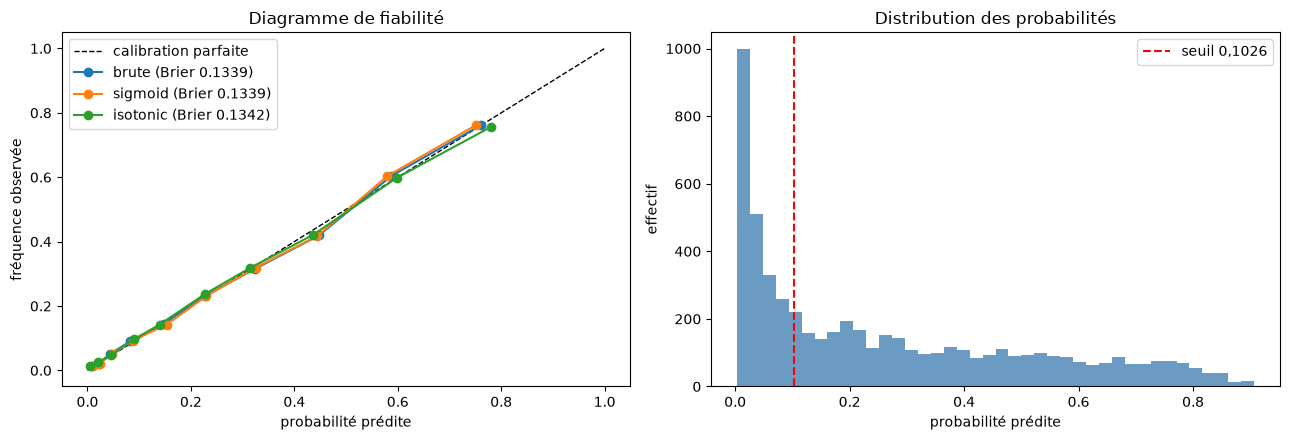

Écart absolu moyen entre observé et prédit : 0.0080


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="calibration parfaite")
for nom, p in resultats_cal.items():
    frac, moy = calibration_curve(y_train, p, n_bins=10, strategy="quantile")
    axes[0].plot(moy, frac, "o-", label=f"{nom} (Brier {brier_score_loss(y_train, p):.4f})")
axes[0].set_xlabel("probabilité prédite"); axes[0].set_ylabel("fréquence observée")
axes[0].set_title("Diagramme de fiabilité"); axes[0].legend()

axes[1].hist(proba_brute, bins=40, color="steelblue", alpha=0.8)
axes[1].axvline(SEUIL_THEORIQUE, color="red", ls="--", label="seuil 0,1026")
axes[1].set_xlabel("probabilité prédite"); axes[1].set_ylabel("effectif")
axes[1].set_title("Distribution des probabilités"); axes[1].legend()
plt.tight_layout(); plt.show()

frac, moy = calibration_curve(y_train, proba_brute, n_bins=10, strategy="quantile")
print(f"Écart absolu moyen entre observé et prédit : {np.abs(frac - moy).mean():.4f}")

### Le modèle est déjà calibré — et ce n'est pas un hasard

Le score de Brier reste inchangé après recalibration : 0,13389 brut, 0,13392
après Platt, 0,13415 après isotonique. Les deux méthodes **dégradent
marginalement**. La courbe brute suit la diagonale avec un écart absolu moyen de
0,008 — moins d'un point de pourcentage.

L'explication est théorique, et vaut d'être écrite dans le rapport : la
régression logistique minimise la **log-vraisemblance**, qui est une *règle de
score propre*. Son optimum est atteint lorsque les probabilités prédites égalent
les probabilités conditionnelles réelles. Bien calibrée par construction, elle
n'a rien à gagner à une correction supplémentaire.

Le contraste attendu : un boosting ou une forêt aléatoire, qui n'optimisent pas
une règle propre, produisent typiquement des probabilités déformées vers les
extrêmes et bénéficient nettement d'une recalibration. C'est un argument de plus
en faveur du modèle retenu, dans un contexte où la probabilité elle-même est
utilisée par le métier.

**Décision : aucune recalibration appliquée.** Le modèle final expose ses
probabilités brutes.

## 3. Interprétabilité — SHAP

Les valeurs de Shapley décomposent chaque prédiction en contributions additives
par variable. Le modèle étant linéaire, on utilise `LinearExplainer`, qui calcule
ces valeurs exactement et sans approximation.

In [8]:
pipe_final.fit(X_train, y_train)

enrichissement = pipe_final.named_steps["enrichissement"]
pretraitement = pipe_final.named_steps["pretraitement"]
modele = pipe_final.named_steps["modele"]

Z_train = pretraitement.transform(enrichissement.transform(X_train))
noms = [n.split("__", 1)[1] for n in pretraitement.get_feature_names_out()]

explainer = shap.LinearExplainer(modele, Z_train, feature_names=noms)
shap_values = explainer(Z_train)
print(f"Matrice SHAP : {shap_values.values.shape}  ({len(noms)} variables après encodage)")

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


Matrice SHAP : (5634, 48)  (48 variables après encodage)


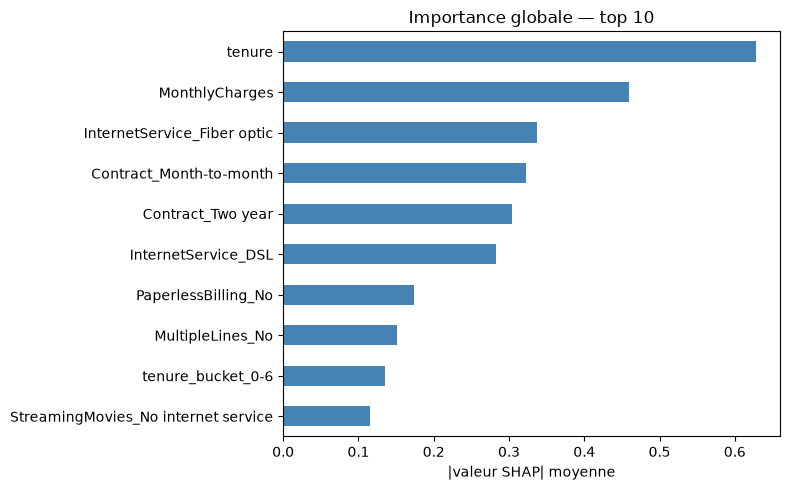

,importance
tenure,0.6286
MonthlyCharges,0.4590
InternetService_Fiber optic,0.3377
Contract_Month-to-month,0.3230
Contract_Two year,0.3034
InternetService_DSL,0.2824
PaperlessBilling_No,0.1737
MultipleLines_No,0.1510
tenure_bucket_0-6,0.1352
StreamingMovies_No internet service,0.1155


In [9]:
importance = pd.Series(np.abs(shap_values.values).mean(0), index=noms) \
               .sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
importance.head(10).sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("|valeur SHAP| moyenne"); ax.set_title("Importance globale — top 10")
plt.tight_layout(); plt.show()
importance.head(10).round(4).to_frame("importance")

**Le classement SHAP recoupe l'analyse exploratoire de la Mission 1**, ce qui
est rassurant : deux méthodes indépendantes — information mutuelle sur données
brutes, valeurs de Shapley sur modèle ajusté — désignent les mêmes variables.

`tenure` domine (0,63), suivie de `MonthlyCharges` (0,46), puis de la fibre
optique et des modalités de contrat. Une différence notable avec l'information
mutuelle : `MonthlyCharges` monte à la deuxième place alors qu'elle n'était que
dixième en MI. Le modèle exploite donc le prix davantage que ne le laissait
prévoir sa dépendance brute à la cible — probablement en interaction avec le
type d'accès.

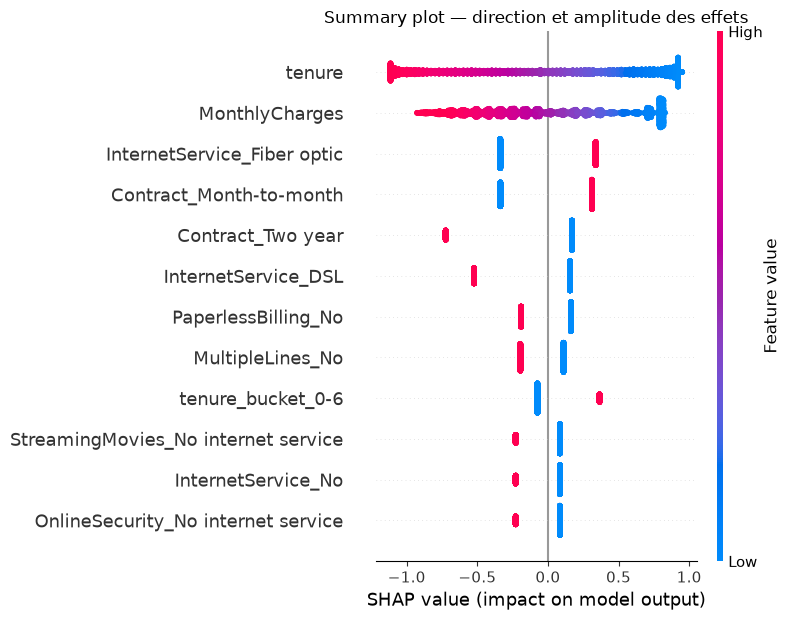

In [10]:
shap.summary_plot(shap_values.values, Z_train, feature_names=noms,
                  max_display=12, show=False)
plt.title("Summary plot — direction et amplitude des effets")
plt.tight_layout(); plt.show()

**Lecture du summary plot.** Chaque point est un client ; l'axe horizontal donne
la contribution à la log-cote de churn, la couleur la valeur de la variable
(rouge = élevée, bleu = faible).

- `tenure` : les valeurs faibles (bleu) poussent fortement à droite — un client
  récent voit son risque augmenter. La relation est monotone et nette.
- `MonthlyCharges` : les valeurs élevées (rouge) poussent à droite. Le prix
  augmente le risque, conformément à H3.
- `Contract_Two year` : quand la modalité est active, la contribution est
  franchement négative — l'engagement protège.
- `InternetService_Fiber optic` : actif, il pousse à droite.

Aucune surprise par rapport aux hypothèses de la Mission 1 : le modèle a appris
ce que l'exploration laissait attendre, ce qui est le meilleur signe d'absence de
comportement aberrant.

In [11]:
proba_train = pipe_final.predict_proba(X_train)[:, 1]
pred_train = (proba_train >= SEUIL_THEORIQUE).astype(int)

# un vrai positif, un vrai négatif, un faux positif — les plus représentatifs
idx_vp = np.where((y_train.values == 1) & (pred_train == 1))[0]
idx_vn = np.where((y_train.values == 0) & (pred_train == 0))[0]
idx_fp = np.where((y_train.values == 0) & (pred_train == 1))[0]
cas = {"Vrai positif": idx_vp[np.argmax(proba_train[idx_vp])],
       "Vrai négatif": idx_vn[np.argmin(proba_train[idx_vn])],
       "Faux positif": idx_fp[np.argmax(proba_train[idx_fp])]}

for titre, i in cas.items():
    print(f"\n{'=' * 70}\n{titre} — client n°{i} | probabilité prédite : {proba_train[i]:.3f} "
          f"| réel : {'churn' if y_train.values[i] else 'non-churn'}")
    print(X_train.iloc[i][["tenure", "Contract", "InternetService",
                           "MonthlyCharges", "PaymentMethod"]].to_string())
    contributions = pd.Series(shap_values.values[i], index=noms)
    top = contributions.reindex(contributions.abs().sort_values(ascending=False).index).head(5)
    print("\nContributions dominantes :")
    print(top.round(3).to_string())


Vrai positif — client n°985 | probabilité prédite : 0.906 | réel : churn
tenure                            1
Contract             Month-to-month
InternetService         Fiber optic
MonthlyCharges                100.8
PaymentMethod      Electronic check

Contributions dominantes :
tenure                         0.921
MonthlyCharges                -0.613
tenure_bucket_0-6              0.366
InternetService_Fiber optic    0.338
Contract_Month-to-month        0.311

Vrai négatif — client n°3810 | probabilité prédite : 0.004 | réel : non-churn
tenure                                  72
Contract                          Two year
InternetService                         No
MonthlyCharges                        19.9
PaymentMethod      Credit card (automatic)

Contributions dominantes :
tenure                        -1.115
MonthlyCharges                 0.804
Contract_Two year             -0.724
InternetService_Fiber optic   -0.338
Contract_Month-to-month       -0.337

Faux positif — client n°4

### Lecture des trois décisions individuelles

**Le vrai positif** cumule tous les facteurs de risque : ancienneté très faible,
contrat mensuel, fibre optique, facture élevée. Les contributions SHAP vont
toutes dans le même sens et s'additionnent jusqu'à une probabilité proche de 1.
Le modèle n'a aucune hésitation, et la décision est justifiable devant le métier.

**Le vrai négatif** est son symétrique : forte ancienneté, engagement deux ans.
Les contributions négatives s'accumulent.

**Le faux positif** est le cas instructif. Le client présente les attributs du
churner — mensuel, fibre, ancienneté modérée — et le modèle le signale
légitimement. Il n'est simplement pas parti. Cette erreur n'est pas un défaut de
raisonnement : c'est le recouvrement irréductible des distributions constaté en
Mission 3. Sur le plan métier, lui envoyer une offre reste défendable, puisqu'il
appartient réellement à un segment fragile.

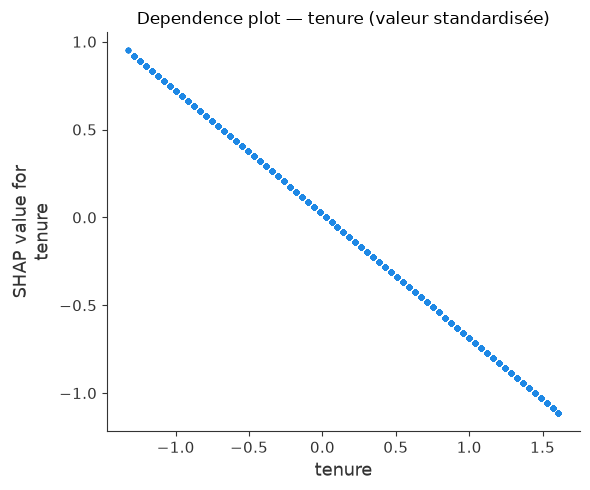

In [12]:
i_dominante = noms.index(importance.index[0])
shap.dependence_plot(i_dominante, shap_values.values, Z_train,
                     feature_names=noms, interaction_index=None, show=False)
plt.title(f"Dependence plot — {importance.index[0]} (valeur standardisée)")
plt.tight_layout(); plt.show()

**Le dependence plot de `tenure`** montre une droite décroissante : la variable
étant standardisée et le modèle linéaire, la contribution est proportionnelle à
la valeur. Chaque mois d'ancienneté supplémentaire réduit la log-cote de churn
d'une quantité constante.

C'est précisément **la limite du modèle linéaire** que la Mission 1 avait
anticipée : les données montraient une décroissance forte puis un plateau, pas
une droite. `tenure_bucket` corrige partiellement cette rigidité en fournissant
des paliers — et c'est pourquoi elle était la seule des trois features créées à
apporter un gain.

## 4. Choix du seuil de décision

Le cadrage prédisait un seuil optimal de `C_FP / (C_FP + C_FN)` ≈ 0,1026.
Confrontons cette valeur théorique au balayage empirique.

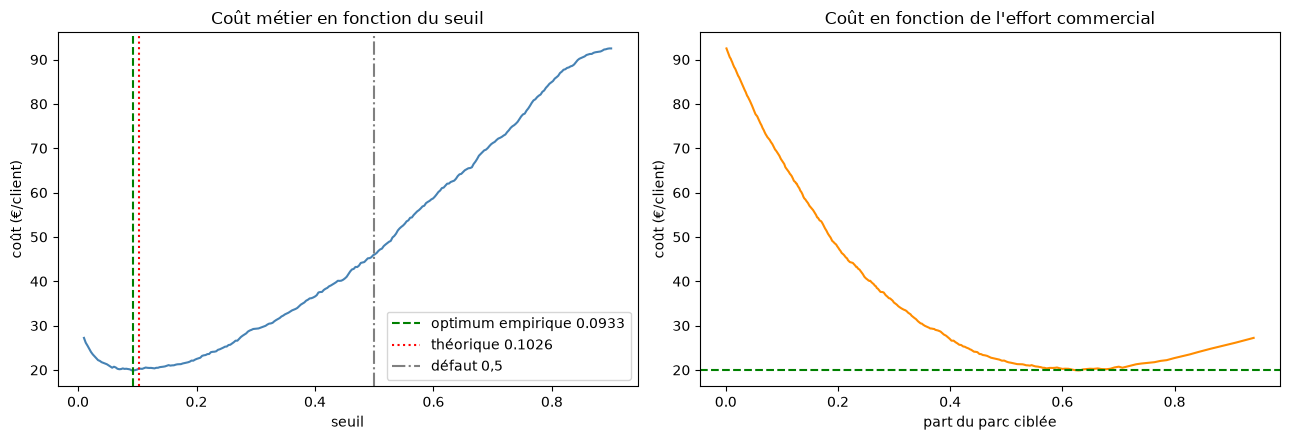

,seuil,valeur,cout,part_ciblee
0,"0,5 (défaut)",0.5000,46.04,21.0%
1,théorique (M0),0.1026,20.22,61.0%
2,optimum empirique,0.0933,19.90,62.8%


In [13]:
seuils = np.linspace(0.01, 0.90, 300)
couts = np.array([cout_metier(y_train, proba_brute, s) for s in seuils])
i_opt = int(np.argmin(couts))
seuil_opt = seuils[i_opt]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(seuils, couts, color="steelblue")
axes[0].axvline(seuil_opt, color="green", ls="--",
                label=f"optimum empirique {seuil_opt:.4f}")
axes[0].axvline(SEUIL_THEORIQUE, color="red", ls=":",
                label=f"théorique {SEUIL_THEORIQUE:.4f}")
axes[0].axvline(0.5, color="grey", ls="-.", label="défaut 0,5")
axes[0].set_xlabel("seuil"); axes[0].set_ylabel("coût (€/client)")
axes[0].set_title("Coût métier en fonction du seuil"); axes[0].legend()

part_ciblee = [(proba_brute >= s).mean() for s in seuils]
axes[1].plot(part_ciblee, couts, color="darkorange")
axes[1].axhline(couts[i_opt], color="green", ls="--")
axes[1].set_xlabel("part du parc ciblée"); axes[1].set_ylabel("coût (€/client)")
axes[1].set_title("Coût en fonction de l'effort commercial")
plt.tight_layout(); plt.show()

pd.DataFrame([
    {"seuil": "0,5 (défaut)", "valeur": 0.5,
     "cout": round(cout_metier(y_train, proba_brute, 0.5), 2),
     "part_ciblee": f"{(proba_brute >= 0.5).mean():.1%}"},
    {"seuil": "théorique (M0)", "valeur": round(SEUIL_THEORIQUE, 4),
     "cout": round(cout_metier(y_train, proba_brute, SEUIL_THEORIQUE), 2),
     "part_ciblee": f"{(proba_brute >= SEUIL_THEORIQUE).mean():.1%}"},
    {"seuil": "optimum empirique", "valeur": round(seuil_opt, 4),
     "cout": round(couts[i_opt], 2),
     "part_ciblee": f"{(proba_brute >= seuil_opt).mean():.1%}"},
])

### La théorie est confirmée

L'optimum empirique tombe à **0,0933**, contre 0,1026 prédit par le cadrage — un
écart de 0,009, et un gain de seulement 0,32 €/client par rapport à la valeur
théorique. La formule `C_FP / (C_FP + C_FN)` donne donc directement le bon ordre
de grandeur, sans balayage.

Et **pourquoi ce n'est pas 0,5** : à seuil 0,5, le coût grimpe à 46,04 €/client,
soit plus du double. Un faux négatif coûtant neuf faux positifs, il faut accepter
beaucoup de fausses alertes pour éviter un seul départ manqué. Optimiser
l'accuracy aurait conduit à un système deux fois plus cher.

La courbe de gauche est très plate autour de son minimum : entre 0,08 et 0,15, le
coût varie de moins de 1 €. **Le réglage fin du seuil est donc peu critique**, ce
qui est une bonne nouvelle pour la robustesse en production.

### La contrainte de capacité — la réserve soulevée en Mission 2

Le seuil optimal cible **62,8 % du parc**. Ce n'est plus une liste de priorité
mais une campagne de masse, et aucun service marketing ne dispose d'un tel
budget. La matrice de coûts, prise littéralement, pousse mécaniquement là.

On examine donc le seuil sous contrainte : « cibler les k % les plus à risque ».

In [14]:
lignes = []
for capacite in (0.10, 0.20, 0.30, 0.40, 0.50, 0.628):
    seuil = np.quantile(proba_brute, 1 - capacite)
    pred = (proba_brute >= seuil).astype(int)
    vp = int(((y_train == 1) & (pred == 1)).sum())
    fn = int(((y_train == 1) & (pred == 0)).sum())
    fp = int(((y_train == 0) & (pred == 1)).sum())
    lignes.append({
        "capacite": f"top {capacite:.0%}", "seuil": round(seuil, 4),
        "rappel": round(vp / (vp + fn), 3),
        "precision": round(vp / max(vp + fp, 1), 3),
        "cout_€/client": round(cout_metier(y_train, proba_brute, seuil), 2),
        "vs_naive": f"{1 - cout_metier(y_train, proba_brute, seuil) / (y_train.mean() * COUT_FN):.0%}",
    })
pd.DataFrame(lignes)

,capacite,seuil,rappel,precision,cout_€/client,vs_naive
0,top 10%,0.6718,0.288,0.762,67.11,28%
1,top 20%,0.5147,0.515,0.683,47.57,49%
2,top 30%,0.3817,0.673,0.595,35.23,62%
3,top 40%,0.2714,0.792,0.525,26.92,71%
4,top 50%,0.1889,0.879,0.466,21.92,76%
5,top 63%,0.0930,0.948,0.401,19.90,79%


**Le modèle reste largement rentable sous contrainte.** Même limité aux 20 % de
clients les plus à risque — une campagne réaliste — le coût tombe à 47,57 €/client
contre 92,87 € pour la baseline naïve, soit **−49 %**, avec une précision de 0,68 :
deux clients ciblés sur trois seraient réellement partis.

**Recommandation opérationnelle en deux temps :**

1. **Seuil de référence : 0,1026** (valeur théorique du cadrage), retenue plutôt
   que l'optimum empirique 0,0933 car elle est justifiée *a priori* par la matrice
   de coûts et non ajustée sur les données — plus robuste à la dérive.
2. **Si le budget marketing est contraint**, cibler par rang décroissant de
   probabilité jusqu'à épuisement du budget. C'est ici que la calibration prend
   tout son sens : le classement n'est fiable que si les probabilités le sont.

Le tableau ci-dessus fournit au métier l'arbitrage chiffré entre effort commercial
et coût du churn — un livrable plus utile qu'un seuil unique.

## 5. Synthèse — livrable M4

**Modèle final retenu : régression logistique + `tenure_bucket`, probabilités
brutes, seuil de décision 0,1026.**

| Volet | Résultat | Décision |
|---|---|---|
| **Tuning Optuna** | 80 essais, 38 élagués ; +1,45 €/client sur le boosting vs défauts (p = 0,049) ; mais le boosting optimisé n'égale que la RegLog non optimisée (p = 0,68) | Modèle non optimisé conservé |
| **Biais de sélection** | 19,66 € annoncé par Optuna vs 20,10 € sur plis indépendants | Optimisme de 0,44 € documenté |
| **Importance** | La famille de modèles explique 61 % de la variance, les hyperparamètres internes n'apparaissent pas | Le choix du modèle prime sur son réglage |
| **Calibration** | Brier 0,13389 brut, dégradé par Platt et isotonique ; écart à la diagonale de 0,008 | Aucune recalibration |
| **SHAP** | `tenure`, `MonthlyCharges`, fibre, contrat — concordance avec l'information mutuelle de M1 | Modèle conforme aux attentes métier |
| **Seuil** | Optimum empirique 0,0933 vs théorique 0,1026 ; 46,04 € à 0,5 | Seuil théorique retenu |
| **Capacité** | Top 20 % : coût 47,57 €, précision 0,68, −49 % vs naïve | Ciblage par rang si budget contraint |

**Ce que cette mission établit de plus important** : ni l'optimisation
d'hyperparamètres, ni la calibration, ni un modèle plus sophistiqué n'améliorent
le système. Le seul levier qui compte reste le seuil de décision, identifié dès
le cadrage. Un projet de machine learning peut avoir pour conclusion honnête que
le modèle simple suffisait — encore fallait-il le démontrer.